⚠  Mall_Customers.csv not found — generating synthetic data.

  CUSTOMER SEGMENTATION — DATA OVERVIEW
  Shape        : 200 rows × 5 columns
  Columns      : ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
  Missing vals : 0
  Duplicates   : 0
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   45.45               79.60                   48.34
std         57.88   14.62               37.13                   28.50
min          1.00   18.00               15.00                    1.00
25%         50.75   34.75               47.00                   24.75
50%        100.50   46.00               83.00                   48.00
75%        150.25   57.00              113.00                   73.00
max        200.00   69.00              139.00                   99.00


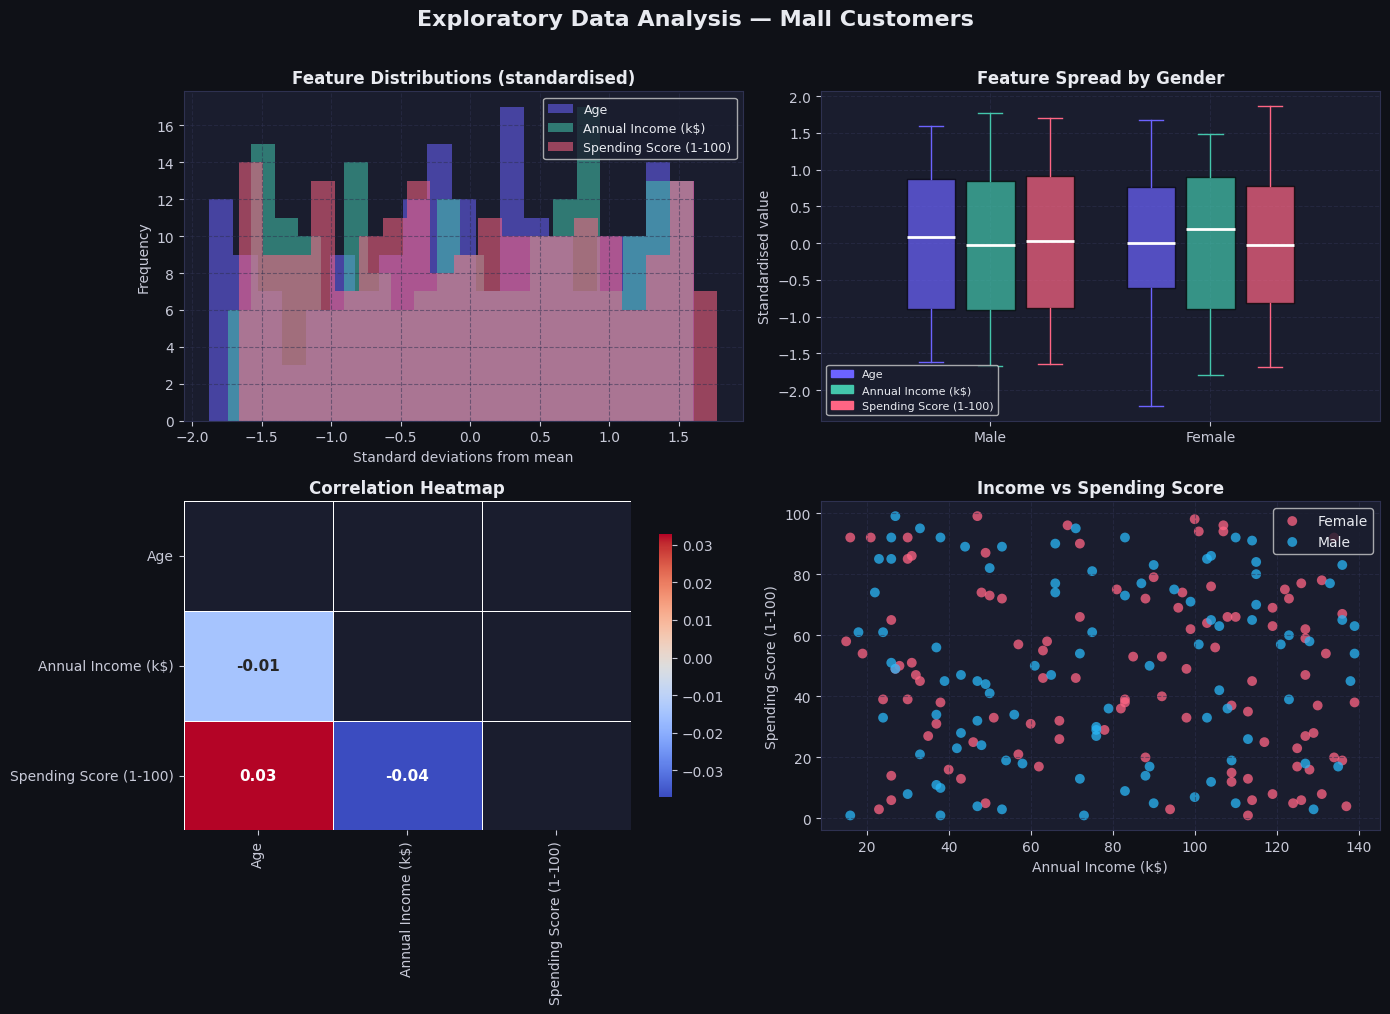

✅  EDA chart saved → eda_analysis.png


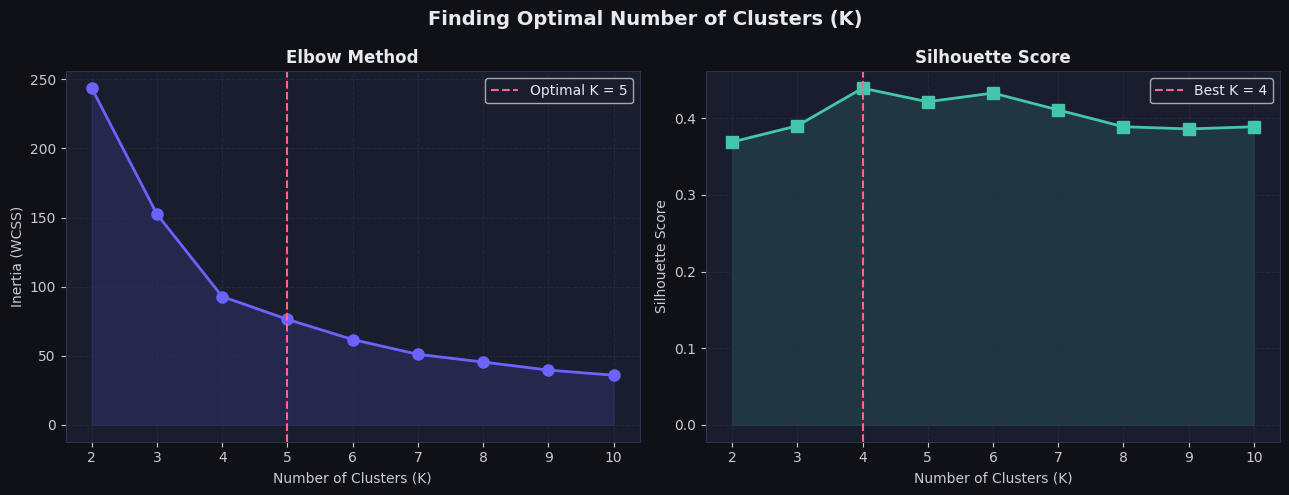

✅  Elbow chart saved → elbow_silhouette.png
    Recommended K = 5  (Silhouette best = 4)

  CLUSTER SUMMARY
                    Count  Avg_Age  Avg_Income  Avg_Spending
Segment                                                     
Budget Conscious       27     45.4        42.6          14.7
Careful Spenders       45     45.7       115.0          20.8
Impulsive Buyers       30     45.9        42.3          84.1
Premium Targets        45     45.7        54.4          43.9
Standard Customers     53     44.8       110.8          72.4


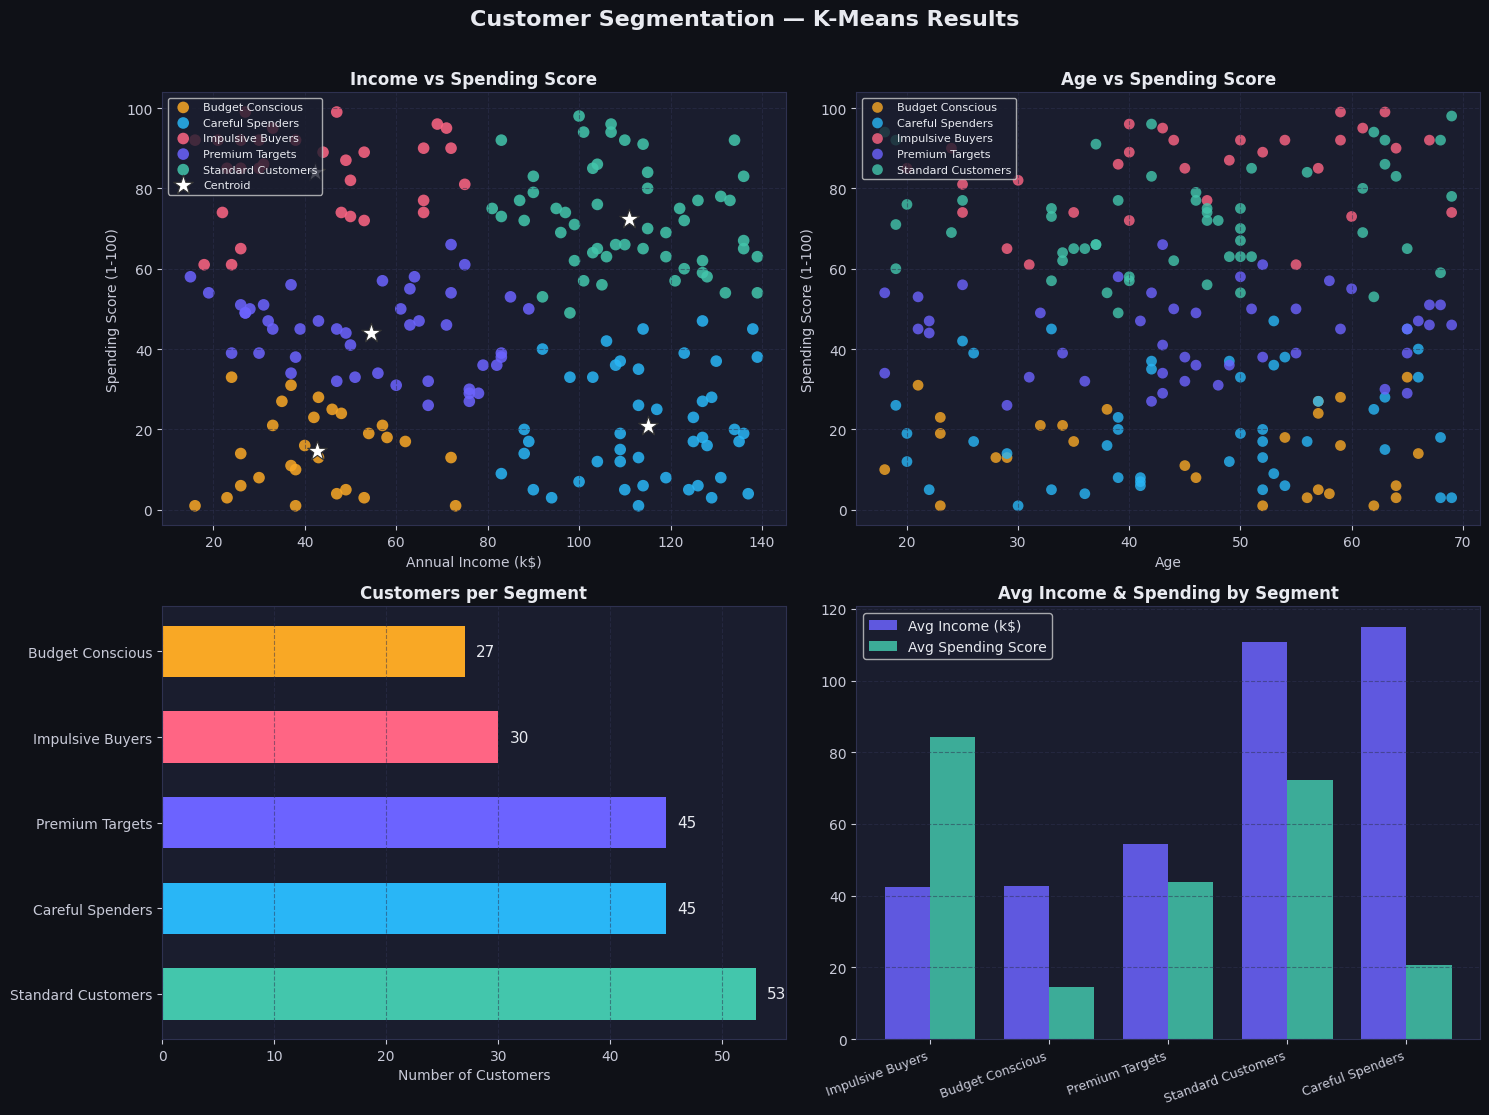

✅  Cluster chart saved → cluster_visualisation.png

✅  Power BI export saved → segmented_customers.csv
    Rows: 200  |  Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Segment']

── Power BI Dashboard Checklist ──────────────────────
  ☐  Import segmented_customers.csv into Power BI
  ☐  Add Segment slicer
  ☐  KPI cards : Total Customers | Avg Income | Avg Spending
  ☐  Scatter   : Income vs Spending Score (color by Segment)
  ☐  Bar chart : Customer count per Segment
  ☐  Donut     : Gender split per Segment
  ☐  Table     : Segment summary (Avg Age, Income, Spending)
─────────────────────────────────────────────────────

🎉  Project complete!
    Files created:
      • eda_analysis.png
      • elbow_silhouette.png
      • cluster_visualisation.png
      • segmented_customers.csv  ← import into Power BI


In [6]:
# ============================================================
# CUSTOMER SEGMENTATION PROJECT
# Author  : Rinkle Yadav
# Tools   : Python | Pandas | Scikit-learn | Matplotlib | Seaborn
# Dataset : Mall Customers (Kaggle)
# ============================================================

# ── IMPORTS ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── PLOT STYLE ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2e3150',
    'axes.labelcolor':  '#c8cad8',
    'xtick.color':      '#c8cad8',
    'ytick.color':      '#c8cad8',
    'text.color':       '#e8eaf0',
    'grid.color':       '#2e3150',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

SEGMENT_COLORS = {
    'Premium Targets':    '#6C63FF',
    'Impulsive Buyers':   '#FF6584',
    'Standard Customers': '#43C6AC',
    'Budget Conscious':   '#F9A825',
    'Careful Spenders':   '#29B6F6',
}
PALETTE = list(SEGMENT_COLORS.values())


# ════════════════════════════════════════════════════════════
# STEP 1 — LOAD & INSPECT DATA
# ════════════════════════════════════════════════════════════
def load_data(filepath='Mall_Customers.csv'):
    """
    Load the Mall Customers dataset.
    Download from: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial
    """
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        # ── Generate synthetic data if CSV not available ──
        print("⚠  Mall_Customers.csv not found — generating synthetic data.\n")
        np.random.seed(42)
        n = 200
        df = pd.DataFrame({
            'CustomerID':             range(1, n + 1),
            'Genre':                  np.random.choice(['Male', 'Female'], n, p=[0.44, 0.56]),
            'Age':                    np.random.randint(18, 70, n),
            'Annual Income (k$)':     np.random.randint(15, 140, n),
            'Spending Score (1-100)': np.random.randint(1, 100, n),
        })

    print("=" * 55)
    print("  CUSTOMER SEGMENTATION — DATA OVERVIEW")
    print("=" * 55)
    print(f"  Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  Columns      : {list(df.columns)}")
    print(f"  Missing vals : {df.isnull().sum().sum()}")
    print(f"  Duplicates   : {df.duplicated().sum()}")
    print("=" * 55)
    print(df.describe().round(2))
    return df


# ════════════════════════════════════════════════════════════
# STEP 2 — EXPLORATORY DATA ANALYSIS (EDA)
# ════════════════════════════════════════════════════════════
def run_eda(df):
    """Generate 4-panel EDA figure."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Exploratory Data Analysis — Mall Customers',
                 fontsize=16, fontweight='bold', color='#e8eaf0', y=1.01)

    num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    eda_colors = ['#6C63FF', '#43C6AC', '#FF6584']

    # ── 2-a  Distributions ──────────────────────────────────
    ax = axes[0, 0]
    for col, color in zip(num_cols, eda_colors):
        vals = (df[col] - df[col].mean()) / df[col].std()
        ax.hist(vals, bins=20, alpha=0.55, color=color, label=col, edgecolor='none')
    ax.set_title('Feature Distributions (standardised)', fontweight='bold')
    ax.set_xlabel('Standard deviations from mean')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(True)

    # ── 2-b  Gender boxplots ─────────────────────────────────
    ax = axes[0, 1]
    gender_col = 'Genre' if 'Genre' in df.columns else 'Gender'
    for i, col in enumerate(num_cols):
        offset = (i - 1) * 0.27
        for j, gender in enumerate(df[gender_col].unique()):
            vals = df[df[gender_col] == gender][col].values
            vals_norm = (vals - vals.mean()) / vals.std()
            bp = ax.boxplot(vals_norm,
                            positions=[j + offset],
                            widths=0.22,
                            patch_artist=True,
                            medianprops=dict(color='white', linewidth=2),
                            whiskerprops=dict(color=eda_colors[i]),
                            capprops=dict(color=eda_colors[i]),
                            flierprops=dict(marker='o', color=eda_colors[i],
                                            alpha=0.4, markersize=4))
            bp['boxes'][0].set_facecolor(eda_colors[i])
            bp['boxes'][0].set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(df[gender_col].unique())
    ax.set_title('Feature Spread by Gender', fontweight='bold')
    ax.set_ylabel('Standardised value')
    patches = [mpatches.Patch(color=c, label=l)
               for c, l in zip(eda_colors, num_cols)]
    ax.legend(handles=patches, fontsize=8)
    ax.grid(True)

    # ── 2-c  Correlation heatmap ─────────────────────────────
    ax = axes[1, 0]
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                mask=mask, ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title('Correlation Heatmap', fontweight='bold')

    # ── 2-d  Income vs Spending scatter ─────────────────────
    ax = axes[1, 1]
    gender_palette = {'Male': '#29B6F6', 'Female': '#FF6584'}
    for gender, grp in df.groupby(gender_col):
        color = gender_palette.get(gender, '#c8cad8')
        ax.scatter(grp['Annual Income (k$)'],
                   grp['Spending Score (1-100)'],
                   c=color, label=gender, alpha=0.75,
                   edgecolors='none', s=50)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.set_title('Income vs Spending Score', fontweight='bold')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight',
                facecolor='#0f1117')
    plt.show()
    print("✅  EDA chart saved → eda_analysis.png")


# ════════════════════════════════════════════════════════════
# STEP 3 — FIND OPTIMAL K (ELBOW + SILHOUETTE)
# ════════════════════════════════════════════════════════════
def find_optimal_k(X_scaled, k_range=range(2, 11)):
    """Plot elbow curve and silhouette scores side by side."""
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Finding Optimal Number of Clusters (K)',
                 fontsize=14, fontweight='bold', color='#e8eaf0')

    # Elbow
    ax1.plot(list(k_range), inertias, marker='o', color='#6C63FF',
             linewidth=2, markersize=8)
    ax1.fill_between(list(k_range), inertias, alpha=0.15, color='#6C63FF')
    ax1.axvline(x=5, color='#FF6584', linestyle='--', linewidth=1.5,
                label='Optimal K = 5')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Inertia (WCSS)')
    ax1.set_title('Elbow Method', fontweight='bold')
    ax1.legend()
    ax1.grid(True)

    # Silhouette
    ax2.plot(list(k_range), silhouettes, marker='s', color='#43C6AC',
             linewidth=2, markersize=8)
    ax2.fill_between(list(k_range), silhouettes, alpha=0.15, color='#43C6AC')
    best_k = list(k_range)[silhouettes.index(max(silhouettes))]
    ax2.axvline(x=best_k, color='#FF6584', linestyle='--', linewidth=1.5,
                label=f'Best K = {best_k}')
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Score', fontweight='bold')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight',
                facecolor='#0f1117')
    plt.show()
    print(f"✅  Elbow chart saved → elbow_silhouette.png")
    print(f"    Recommended K = 5  (Silhouette best = {best_k})")
    return 5


# ════════════════════════════════════════════════════════════
# STEP 4 — K-MEANS CLUSTERING
# ════════════════════════════════════════════════════════════
def run_kmeans(df, X_scaled, k=5):
    """Fit K-Means, name segments, return labelled dataframe."""
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['Cluster'] = km.fit_predict(X_scaled)

    # ── Name clusters based on mean Income & Spending ───────
    summary = df.groupby('Cluster')[
        ['Annual Income (k$)', 'Spending Score (1-100)']
    ].mean()

    inc_med = summary['Annual Income (k$)'].median()
    spd_med = summary['Spending Score (1-100)'].median()

    def name_cluster(row):
        high_inc = row['Annual Income (k$)'] >= inc_med
        high_spd = row['Spending Score (1-100)'] >= spd_med
        if high_inc and high_spd:     return 'Premium Targets'
        if not high_inc and high_spd: return 'Impulsive Buyers'
        if high_inc and not high_spd: return 'Careful Spenders'
        if not high_inc and not high_spd: return 'Budget Conscious'
        return 'Standard Customers'

    cluster_map = summary.apply(name_cluster, axis=1).to_dict()

    # Ensure all 5 labels are used
    used = set(cluster_map.values())
    all_names = set(SEGMENT_COLORS.keys())
    missing = list(all_names - used)
    for cid, name in cluster_map.items():
        if name in used and missing:
            dup = [c for c, n in cluster_map.items() if n == name and c != cid]
            if dup:
                cluster_map[cid] = missing.pop()

    df['Segment'] = df['Cluster'].map(cluster_map)

    print("\n" + "=" * 55)
    print("  CLUSTER SUMMARY")
    print("=" * 55)
    report = df.groupby('Segment').agg(
        Count=('CustomerID', 'count'),
        Avg_Age=('Age', 'mean'),
        Avg_Income=('Annual Income (k$)', 'mean'),
        Avg_Spending=('Spending Score (1-100)', 'mean')
    ).round(1)
    print(report.to_string())
    print("=" * 55)
    return df, km


# ════════════════════════════════════════════════════════════
# STEP 5 — VISUALISE CLUSTERS
# ════════════════════════════════════════════════════════════
def plot_clusters(df, km, X_scaled, scaler):
    """4-panel cluster visualisation."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Customer Segmentation — K-Means Results',
                 fontsize=16, fontweight='bold', color='#e8eaf0', y=1.01)

    # ── 5-a  Income vs Spending (main cluster plot) ──────────
    ax = axes[0, 0]
    for seg, grp in df.groupby('Segment'):
        color = SEGMENT_COLORS.get(seg, '#888')
        ax.scatter(grp['Annual Income (k$)'],
                   grp['Spending Score (1-100)'],
                   c=color, label=seg, s=70,
                   alpha=0.85, edgecolors='none')

    # Cluster centroids (inverse-transform back to original scale)
    centroids_orig = scaler.inverse_transform(km.cluster_centers_)
    ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
               s=220, marker='*', c='white',
               edgecolors='#333', linewidths=0.8,
               zorder=5, label='Centroid')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.set_title('Income vs Spending Score', fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True)

    # ── 5-b  Age vs Spending ─────────────────────────────────
    ax = axes[0, 1]
    for seg, grp in df.groupby('Segment'):
        color = SEGMENT_COLORS.get(seg, '#888')
        ax.scatter(grp['Age'], grp['Spending Score (1-100)'],
                   c=color, label=seg, s=60,
                   alpha=0.80, edgecolors='none')
    ax.set_xlabel('Age')
    ax.set_ylabel('Spending Score (1-100)')
    ax.set_title('Age vs Spending Score', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True)

    # ── 5-c  Segment size (bar chart) ───────────────────────
    ax = axes[1, 0]
    counts = df['Segment'].value_counts()
    bars = ax.barh(counts.index,
                   counts.values,
                   color=[SEGMENT_COLORS.get(s, '#888') for s in counts.index],
                   edgecolor='none', height=0.6)
    for bar, val in zip(bars, counts.values):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=11, color='#e8eaf0')
    ax.set_xlabel('Number of Customers')
    ax.set_title('Customers per Segment', fontweight='bold')
    ax.grid(True, axis='x')

    # ── 5-d  Avg Income & Spending by Segment ───────────────
    ax = axes[1, 1]
    seg_stats = df.groupby('Segment')[
        ['Annual Income (k$)', 'Spending Score (1-100)']
    ].mean().sort_values('Annual Income (k$)')
    x = np.arange(len(seg_stats))
    width = 0.38
    b1 = ax.bar(x - width / 2, seg_stats['Annual Income (k$)'],
                width, label='Avg Income (k$)',
                color='#6C63FF', alpha=0.85, edgecolor='none')
    b2 = ax.bar(x + width / 2, seg_stats['Spending Score (1-100)'],
                width, label='Avg Spending Score',
                color='#43C6AC', alpha=0.85, edgecolor='none')
    ax.set_xticks(x)
    ax.set_xticklabels(seg_stats.index, rotation=20, ha='right', fontsize=9)
    ax.set_title('Avg Income & Spending by Segment', fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y')

    plt.tight_layout()
    plt.savefig('cluster_visualisation.png', dpi=150,
                bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print("✅  Cluster chart saved → cluster_visualisation.png")


# ════════════════════════════════════════════════════════════
# STEP 6 — EXPORT CSV FOR POWER BI
# ════════════════════════════════════════════════════════════
def export_for_powerbi(df, filepath='segmented_customers.csv'):
    export_cols = [
        'CustomerID', 'Genre', 'Age',
        'Annual Income (k$)', 'Spending Score (1-100)',
        'Cluster', 'Segment'
    ]
    out = df[[c for c in export_cols if c in df.columns]]
    out.to_csv(filepath, index=False)
    print(f"\n✅  Power BI export saved → {filepath}")
    print(f"    Rows: {len(out)}  |  Columns: {list(out.columns)}")
    print("\n── Power BI Dashboard Checklist ──────────────────────")
    print("  ☐  Import segmented_customers.csv into Power BI")
    print("  ☐  Add Segment slicer")
    print("  ☐  KPI cards : Total Customers | Avg Income | Avg Spending")
    print("  ☐  Scatter   : Income vs Spending Score (color by Segment)")
    print("  ☐  Bar chart : Customer count per Segment")
    print("  ☐  Donut     : Gender split per Segment")
    print("  ☐  Table     : Segment summary (Avg Age, Income, Spending)")
    print("─────────────────────────────────────────────────────")


# ════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ════════════════════════════════════════════════════════════
if __name__ == '__main__':

    # 1. Load
    df = load_data('Mall_Customers.csv')

    # 2. EDA
    run_eda(df)

    # 3. Feature scaling
    features = ['Annual Income (k$)', 'Spending Score (1-100)']
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

    # 4. Optimal K
    optimal_k = find_optimal_k(X_scaled)

    # 5. Clustering
    df, km_model = run_kmeans(df, X_scaled, k=optimal_k)

    # 6. Visualise
    plot_clusters(df, km_model, X_scaled, scaler)

    # 7. Export for Power BI
    export_for_powerbi(df)

    print("\n🎉  Project complete!")
    print("    Files created:")
    print("      • eda_analysis.png")
    print("      • elbow_silhouette.png")
    print("      • cluster_visualisation.png")
    print("      • segmented_customers.csv  ← import into Power BI")